# Data Exploration + Preprocessing: <YOUR NAME>

**How to use this template**
1. **Do not edit this template.** Make a copy, rename it to `eda/eda_<yourname>.ipynb`, and work only in your copy.
2. Run the cells group by group. Under each group, write your findings in the **Findings** cell.
3. In section 8, add at least 2–3 analyses of your own.
4. At the end, fill in the decision table (one row per feature) and save it. This table is what we compare in the team meeting.
5. Upload your notebook and your CSV to the `exploration` branch (see README). Deadline: 11 October, 10:00 (German time).

**Rules**
- Use only the training split (`load_train()`, 80% of the data). Never look at the test split.
- Do not change `src/` without telling the team; everyone relies on it.

**Guiding questions for every group**
- Distribution: skewed? many zeros? strange values (negative, extreme, placeholder like 0 / "Unknown")?
- Missing values: how many, and how should they be handled?
- Relation to churn: does the churn rate change across values?
- Redundancy: are some columns highly correlated or derived from each other?
- Preprocessing: keep or drop? impute how? transform (log, clip, binarise)? encode how?
- Feature engineering: which new features could be useful?

In [1]:
import sys
sys.path.append("..")

import pandas as pd
from src.data import load_train
from src.eda_utils import (FEATURE_GROUPS, overview, churn_signal, churn_rate_by,
                           plot_column, corr_heatmap, summary_skeleton)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

train = load_train()
print(train.shape)
print("churn rate:", round(train["churn"].mean(), 4))

(40837, 59)
churn rate: 0.2882


## 0. Overview of all features

In [2]:
all_cols = [c for cols in FEATURE_GROUPS.values() for c in cols]
overview(train, all_cols)

,type,n_unique,missing_%,placeholder_%,zero_%,negative_%,min,median,p99,max,top_value
column,,,,,,,,,,,
MonthlyRevenue,numeric,11624,0.29,NaN,0.01,0.01,-6.17,48.47,228.3256,1223.38,NaN
TotalRecurringCharge,numeric,207,0.29,NaN,0.34,0.02,-11.00,45.00,120.0000,400.00,NaN
OverageMinutes,numeric,704,0.29,NaN,45.59,0.00,0.00,3.00,434.0000,4321.00,NaN
MonthsInService,numeric,56,0.00,NaN,0.00,0.00,6.00,16.00,49.0000,61.00,NaN
CurrentEquipmentDays,numeric,1397,0.00,NaN,0.04,0.13,-5.00,329.00,1141.6500,1812.00,NaN
Handsets,numeric,22,0.00,NaN,0.00,0.00,1.00,1.00,7.0000,24.00,NaN
HandsetModels,numeric,13,0.00,NaN,0.00,0.00,1.00,1.00,5.0000,15.00,NaN
UniqueSubs,numeric,14,0.00,NaN,0.00,0.00,1.00,1.00,5.0000,18.00,NaN
ActiveSubs,numeric,10,0.00,NaN,0.08,0.00,0.00,1.00,4.0000,9.00,NaN


## 1. Account & billing

Columns: `MonthlyRevenue`, `TotalRecurringCharge`, `OverageMinutes`, `MonthsInService`, `CurrentEquipmentDays`, `Handsets`, `HandsetModels`, `UniqueSubs`, `ActiveSubs`, `AdjustmentsToCreditRating`

In [3]:
cols = FEATURE_GROUPS["account_billing"]
display(overview(train, cols))
display(churn_signal(train, cols))

,type,n_unique,missing_%,placeholder_%,zero_%,negative_%,min,median,p99,max,top_value
column,,,,,,,,,,,
MonthlyRevenue,numeric,11624,0.29,None,0.01,0.01,-6.17,48.47,228.3256,1223.38,None
TotalRecurringCharge,numeric,207,0.29,None,0.34,0.02,-11.00,45.00,120.0000,400.00,None
OverageMinutes,numeric,704,0.29,None,45.59,0.00,0.00,3.00,434.0000,4321.00,None
MonthsInService,numeric,56,0.00,None,0.00,0.00,6.00,16.00,49.0000,61.00,None
CurrentEquipmentDays,numeric,1397,0.00,None,0.04,0.13,-5.00,329.00,1141.6500,1812.00,None
Handsets,numeric,22,0.00,None,0.00,0.00,1.00,1.00,7.0000,24.00,None
HandsetModels,numeric,13,0.00,None,0.00,0.00,1.00,1.00,5.0000,15.00,None
UniqueSubs,numeric,14,0.00,None,0.00,0.00,1.00,1.00,5.0000,18.00,None
ActiveSubs,numeric,10,0.00,None,0.08,0.00,0.00,1.00,4.0000,9.00,None


,auc,signal
column,,
MonthlyRevenue,0.485,0.015
TotalRecurringCharge,0.457,0.043
OverageMinutes,0.511,0.011
MonthsInService,0.528,0.028
CurrentEquipmentDays,0.576,0.076
Handsets,0.482,0.018
HandsetModels,0.479,0.021
UniqueSubs,0.524,0.024
ActiveSubs,0.511,0.011


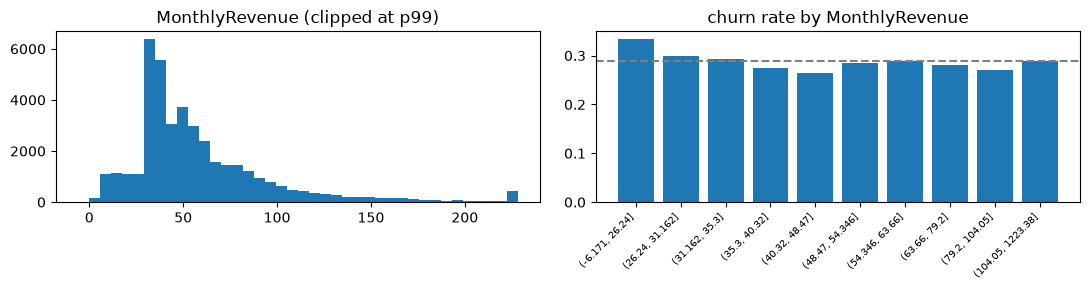

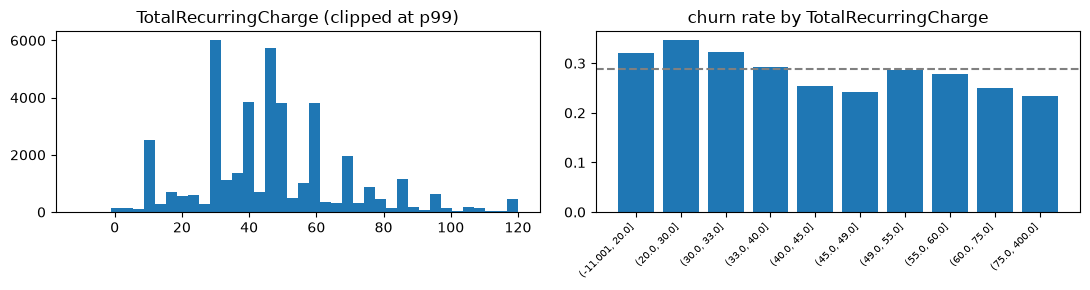

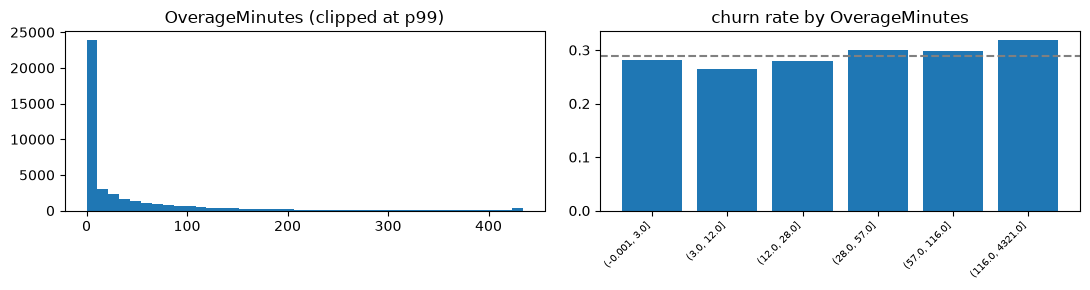

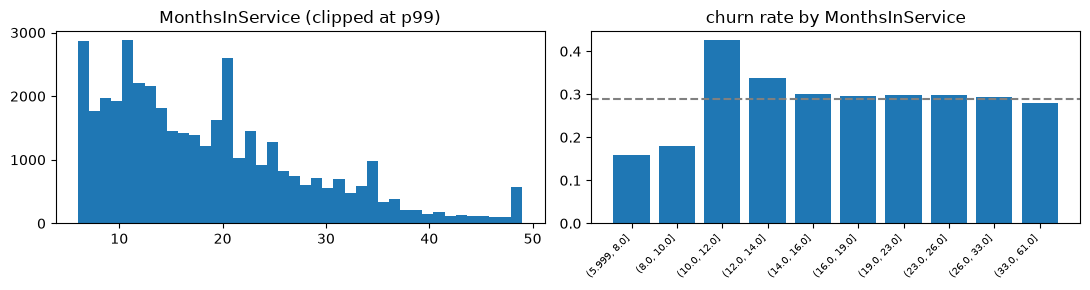

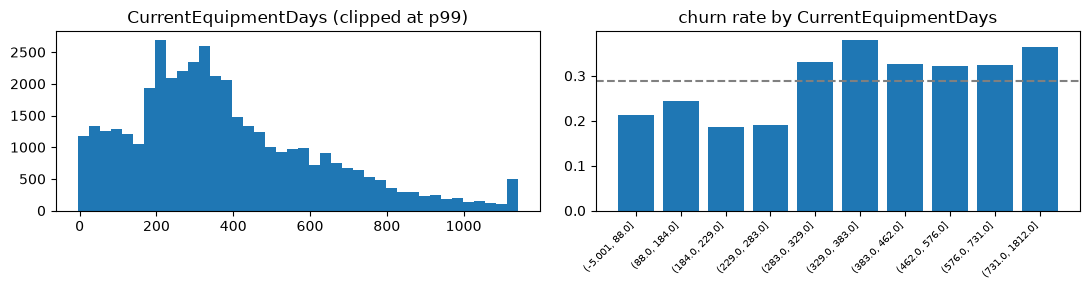

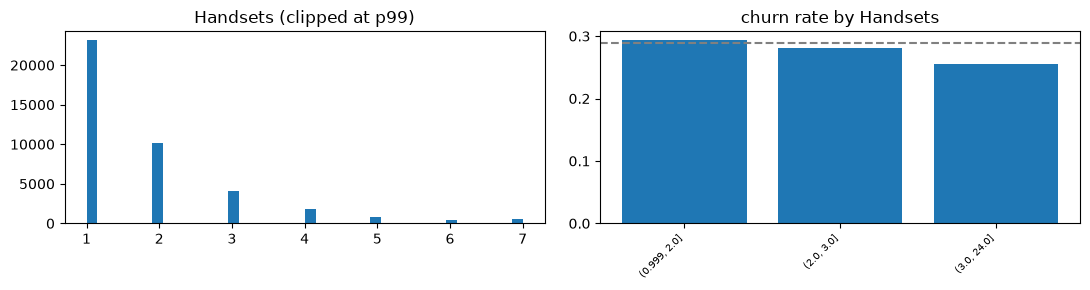

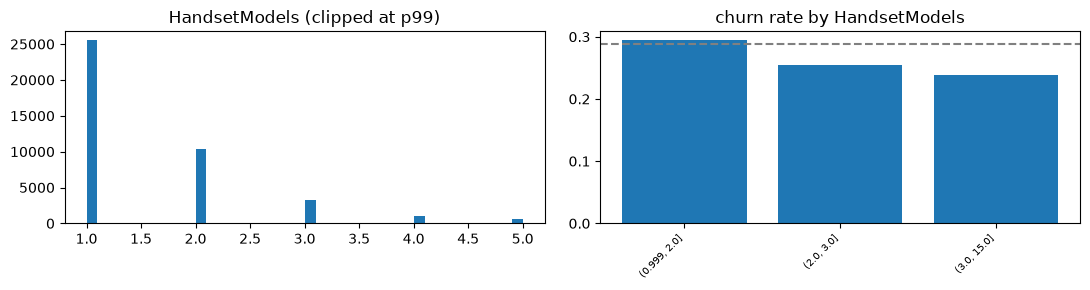

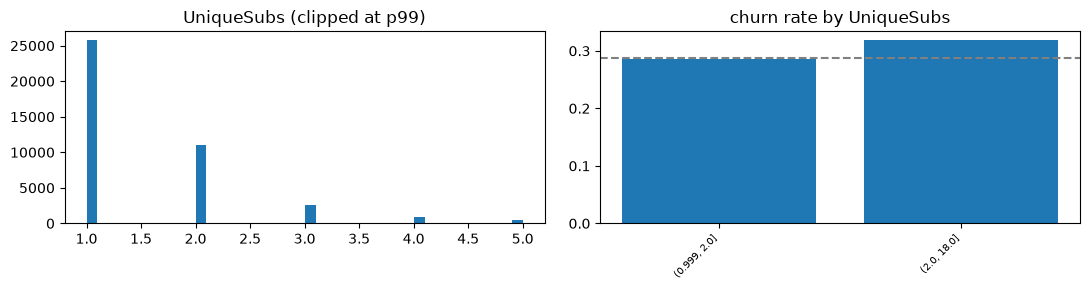

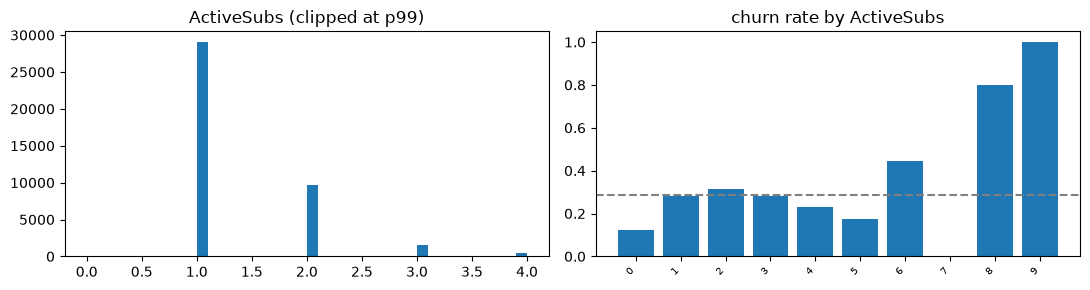

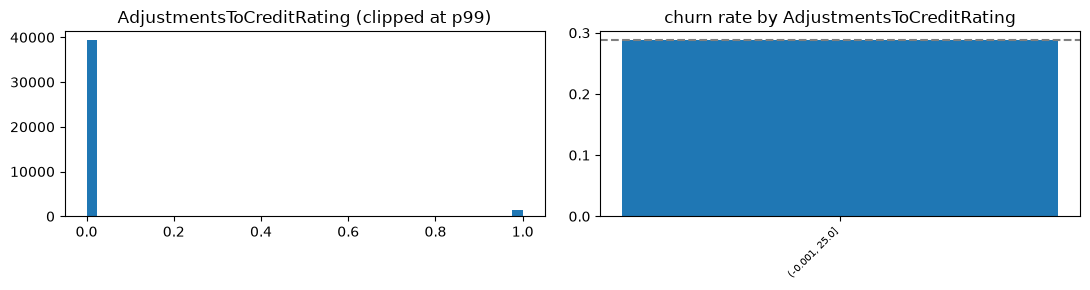

In [4]:
for c in cols:
    plot_column(train, c)

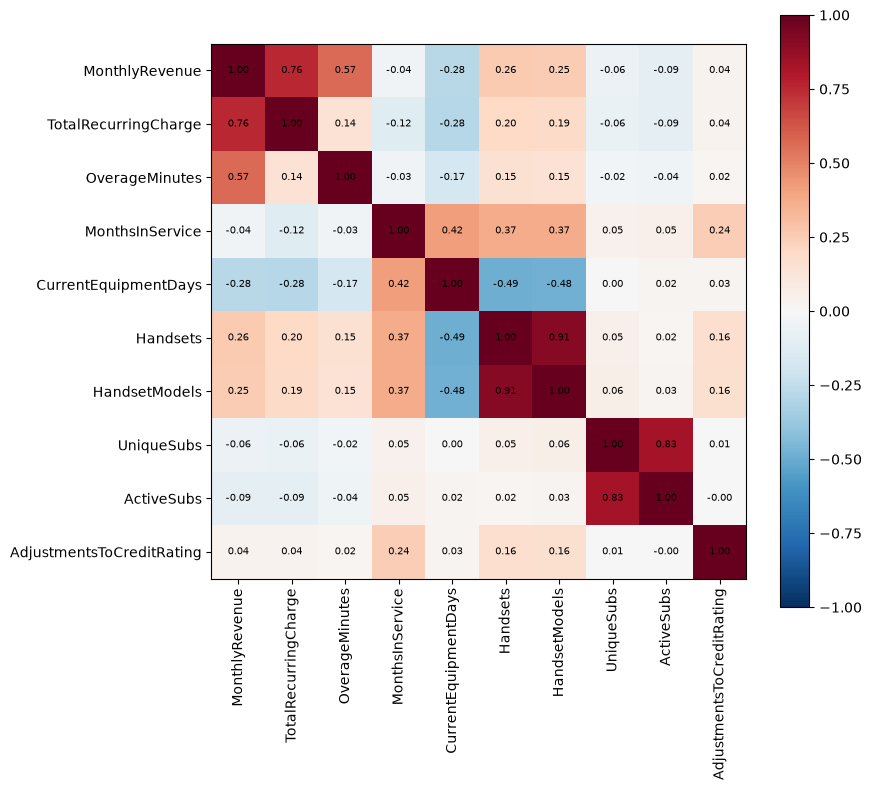

In [5]:
corr = corr_heatmap(train, cols)

**Findings (Account & billing):**

- According to churn rate by MonthinService, Churn is only ~16–18% for customers at 6–10 months, jumps to ~43% at 10–12 months, and then settles around 30%. This most likely reflects the end of a one-year contract.
- Based on churn rate by CurrentEquipmentDays, Handset age matters: churn rises sharply after about one year. Customers with a handset lower than ~300 days churn at ~19–23%; afterwards churn stays at 33–38%. Customers may switch telecom operaters when they want a new phone.
- Overage has only a weak effect. 46% of customers never exceed their plan. Churn rises only slightly with more overage minutes (up to ~32% in the highest group).

## 2. Service usage

Columns: `MonthlyMinutes`, `DirectorAssistedCalls`, `RoamingCalls`, `ThreewayCalls`, `ReceivedCalls`, `OutboundCalls`, `InboundCalls`, `PeakCallsInOut`, `OffPeakCallsInOut`, `CallForwardingCalls`, `CallWaitingCalls`

In [6]:
cols = FEATURE_GROUPS["usage"]
display(overview(train, cols))
display(churn_signal(train, cols))

,type,n_unique,missing_%,placeholder_%,zero_%,negative_%,min,median,p99,max,top_value
column,,,,,,,,,,,
MonthlyMinutes,numeric,2596,0.29,None,1.40,0.0,0.0,367.00,2450.000,7359.00,None
DirectorAssistedCalls,numeric,139,0.29,None,48.02,0.0,0.0,0.25,9.650,159.39,None
RoamingCalls,numeric,484,0.29,None,68.66,0.0,0.0,0.00,21.584,1112.40,None
ThreewayCalls,numeric,76,0.00,None,72.72,0.0,0.0,0.00,4.000,66.00,None
ReceivedCalls,numeric,5694,0.00,None,12.31,0.0,0.0,52.70,772.528,2692.40,None
OutboundCalls,numeric,748,0.00,None,12.54,0.0,0.0,13.70,163.000,644.30,None
InboundCalls,numeric,441,0.00,None,29.23,0.0,0.0,2.00,77.192,519.30,None
PeakCallsInOut,numeric,1745,0.00,None,8.23,0.0,0.0,62.00,493.892,2090.70,None
OffPeakCallsInOut,numeric,1572,0.00,None,8.84,0.0,0.0,35.70,435.700,1438.00,None


,auc,signal
column,,
MonthlyMinutes,0.461,0.039
DirectorAssistedCalls,0.486,0.014
RoamingCalls,0.502,0.002
ThreewayCalls,0.486,0.014
ReceivedCalls,0.472,0.028
OutboundCalls,0.473,0.027
InboundCalls,0.468,0.032
PeakCallsInOut,0.471,0.029
OffPeakCallsInOut,0.467,0.033


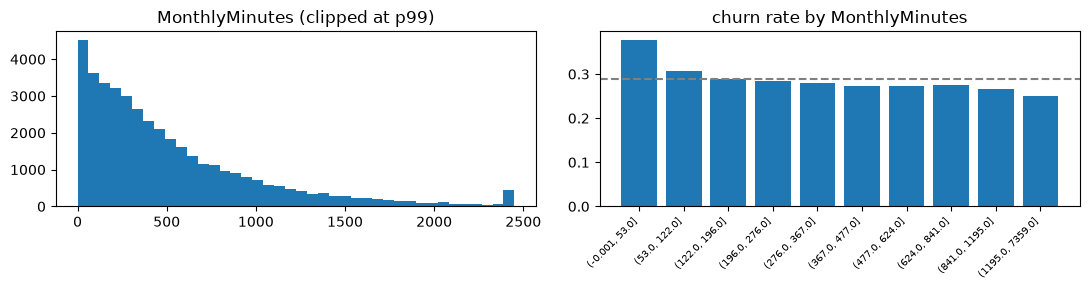

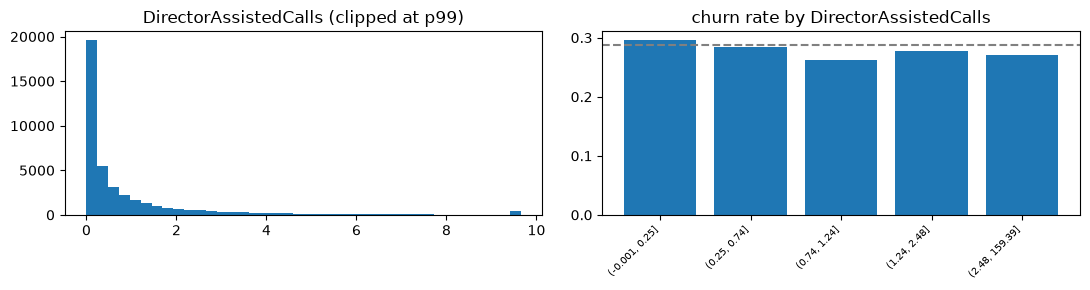

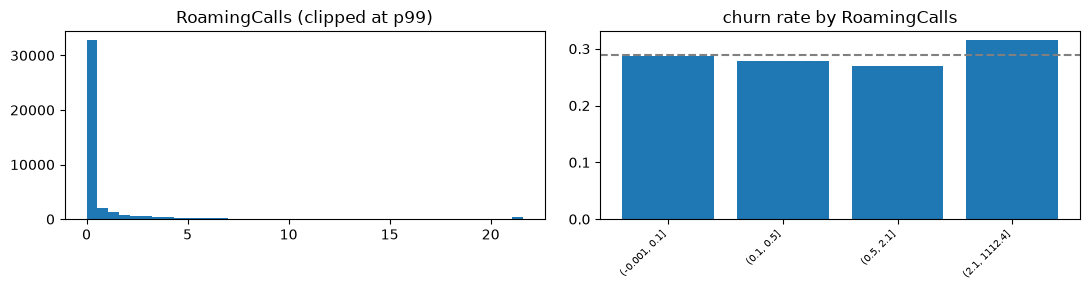

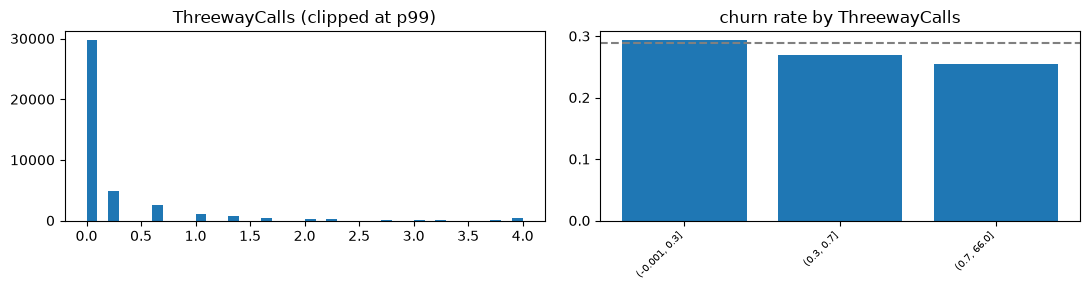

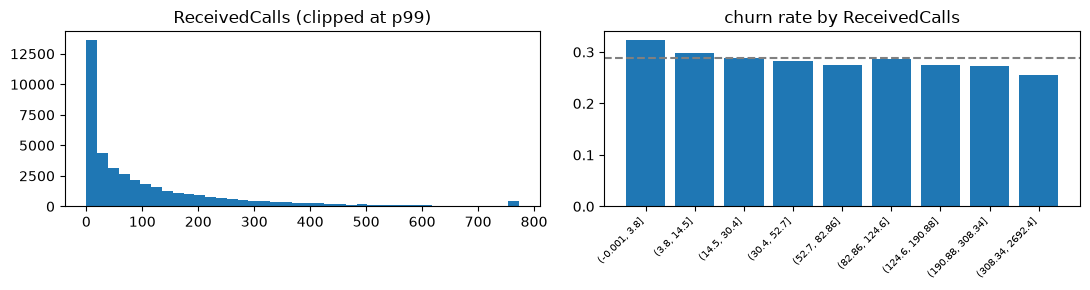

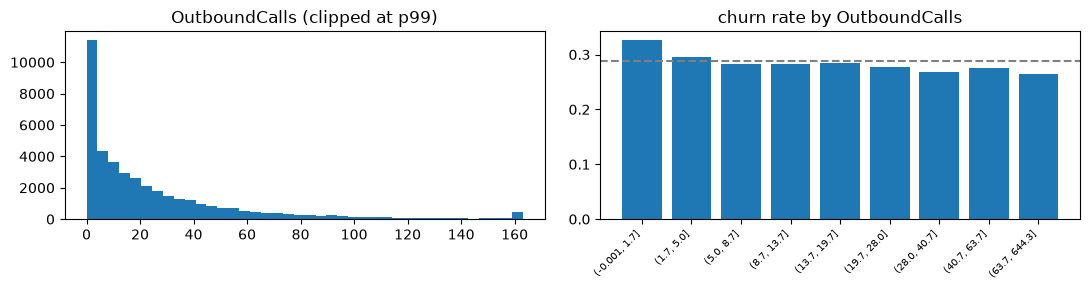

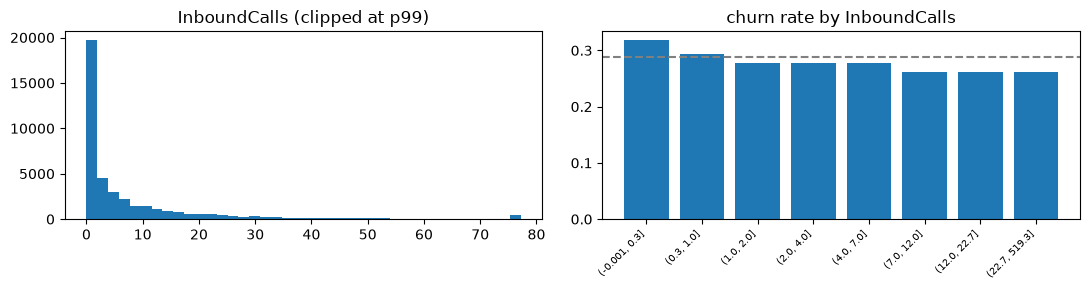

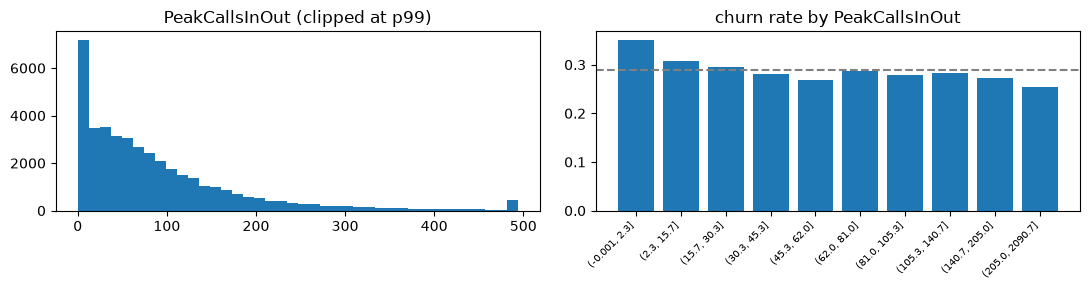

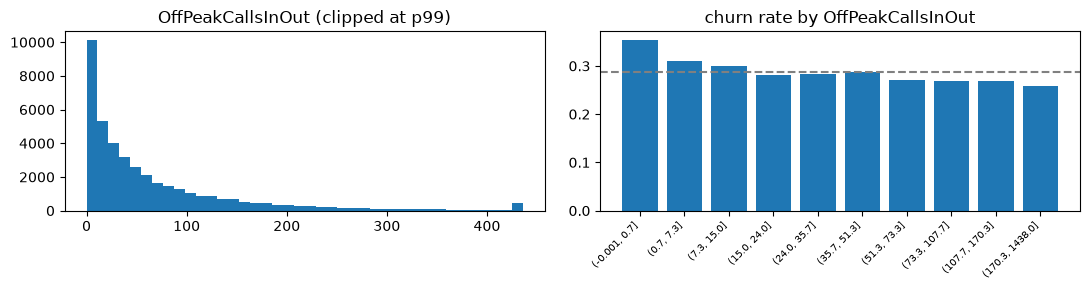

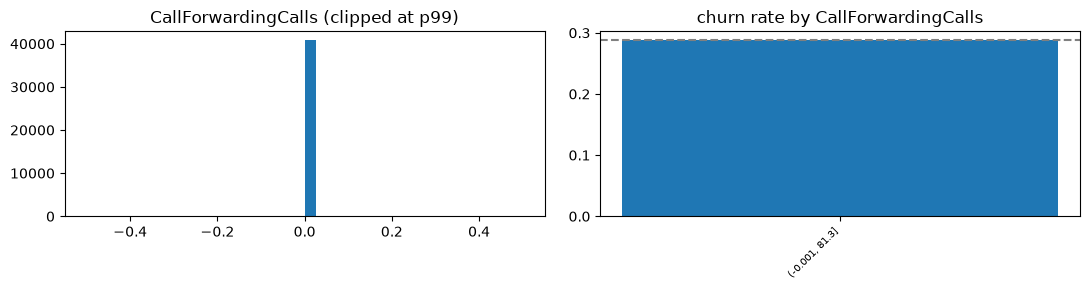

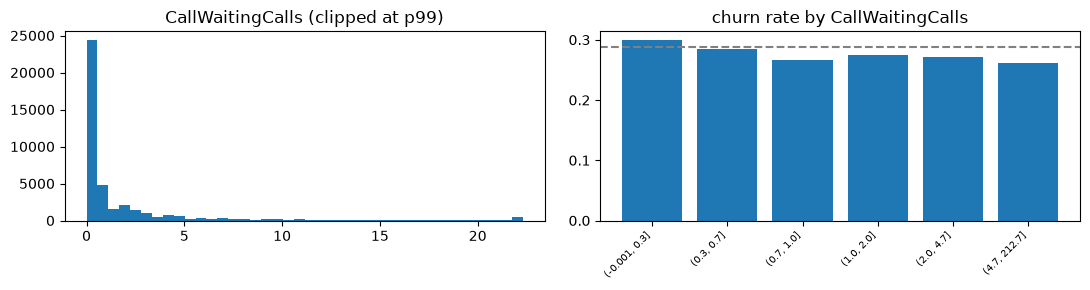

In [7]:
for c in cols:
    plot_column(train, c)

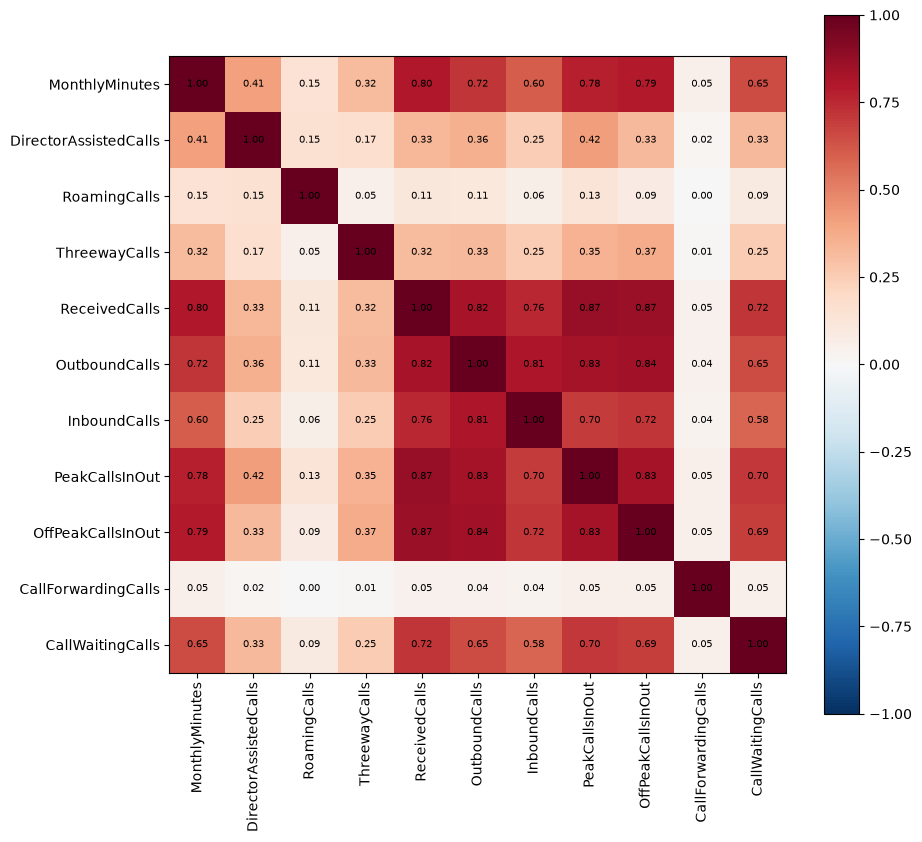

In [8]:
corr = corr_heatmap(train, cols)

**Findings (Service usage):**

- All usage features are weak (AUC 0.46–0.50), but consistently show that lower usage → higher churn. They are heavily right-skewed with many zeros and strongly correlated with each other.
- RoamingCalls, DirectorAssistedCalls and ThreewayCalls show no clear relation to churn; CallForwardingCalls is 0 for 99.6% of customers and carries no information → drop.

## 3. Usage change & retention (check for leakage!)

Columns: `PercChangeMinutes`, `PercChangeRevenues`, `RetentionCalls`, `RetentionOffersAccepted`, `MadeCallToRetentionTeam`, `ReferralsMadeBySubscriber`, `NewCellphoneUser`, `NotNewCellphoneUser`

In [9]:
cols = FEATURE_GROUPS["usage_change_retention"]
display(overview(train, cols))
display(churn_signal(train, cols))

,type,n_unique,missing_%,placeholder_%,zero_%,negative_%,min,median,p99,max,top_value
column,,,,,,,,,,,
PercChangeMinutes,numeric,2138,0.71,None,2.17,52.65,-3406.0,-6.0,741.000,5192.0,NaN
PercChangeRevenues,numeric,2721,0.71,None,11.47,55.56,-1107.7,-0.3,117.616,2483.5,NaN
RetentionCalls,numeric,5,0.00,None,96.57,0.00,0.0,0.0,1.000,4.0,NaN
RetentionOffersAccepted,numeric,4,0.00,None,98.26,0.00,0.0,0.0,1.000,3.0,NaN
MadeCallToRetentionTeam,categorical,2,0.00,None,NaN,NaN,NaN,NaN,NaN,NaN,No
ReferralsMadeBySubscriber,numeric,13,0.00,None,95.23,0.00,0.0,0.0,1.000,35.0,NaN
NewCellphoneUser,categorical,2,0.00,None,NaN,NaN,NaN,NaN,NaN,NaN,No
NotNewCellphoneUser,categorical,2,0.00,None,NaN,NaN,NaN,NaN,NaN,NaN,No


,auc,signal,churn_rate_min,churn_rate_max
column,,,,
PercChangeMinutes,0.469,0.031,NaN,NaN
PercChangeRevenues,0.497,0.003,NaN,NaN
RetentionCalls,0.513,0.013,NaN,NaN
RetentionOffersAccepted,0.506,0.006,NaN,NaN
MadeCallToRetentionTeam,NaN,NaN,0.282,0.449
ReferralsMadeBySubscriber,0.499,0.001,NaN,NaN
NewCellphoneUser,NaN,NaN,0.281,0.290
NotNewCellphoneUser,NaN,NaN,0.286,0.301


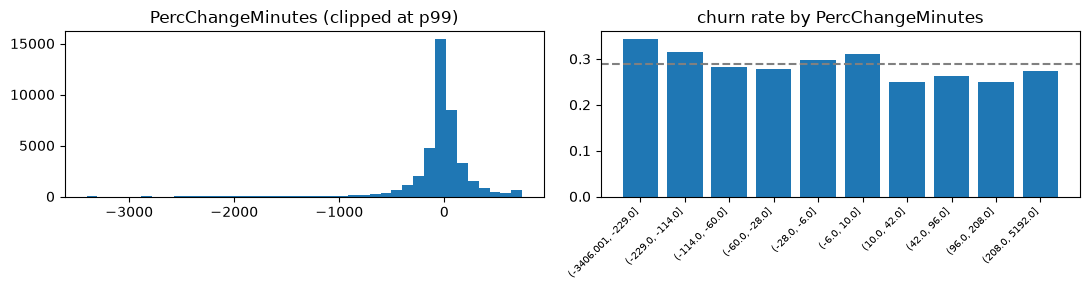

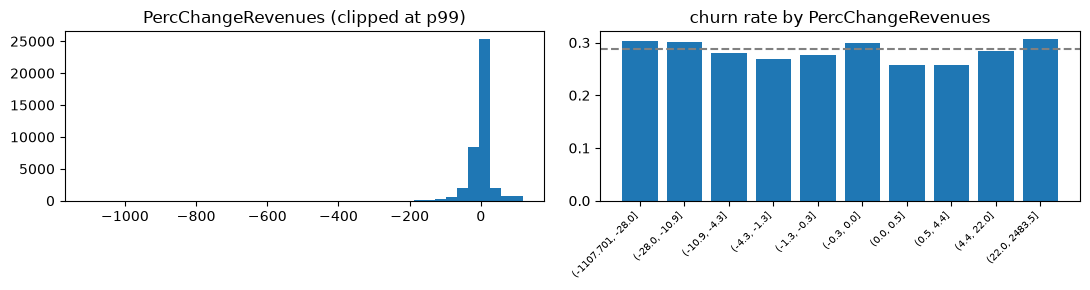

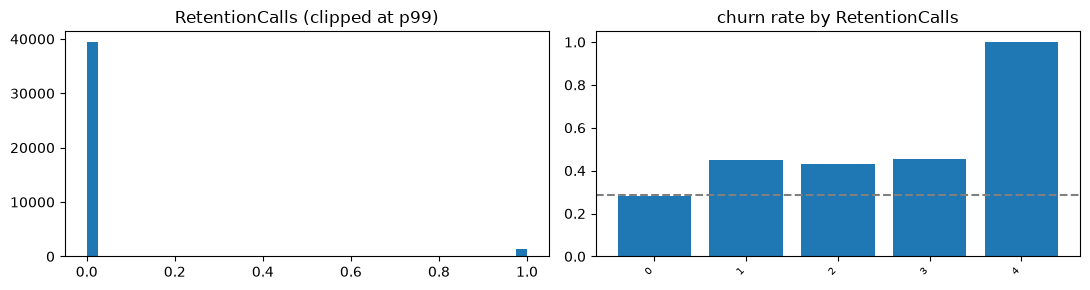

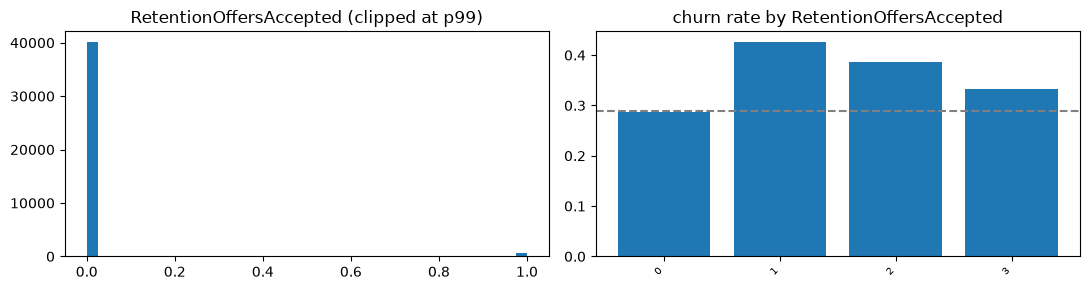

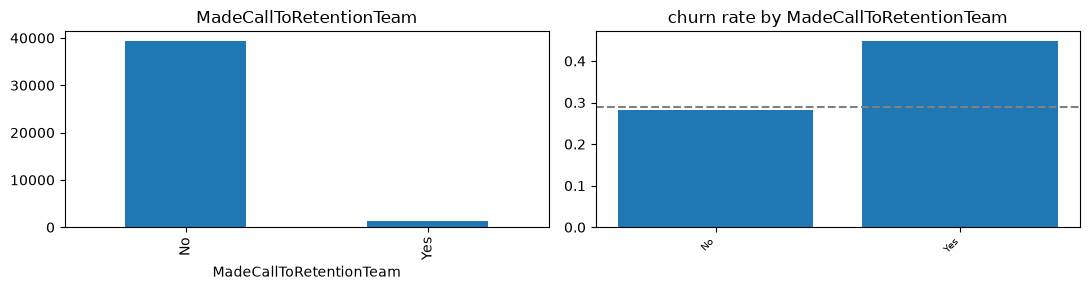

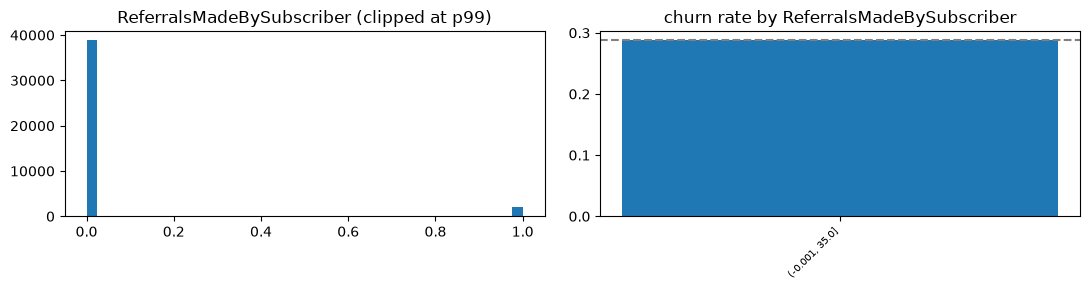

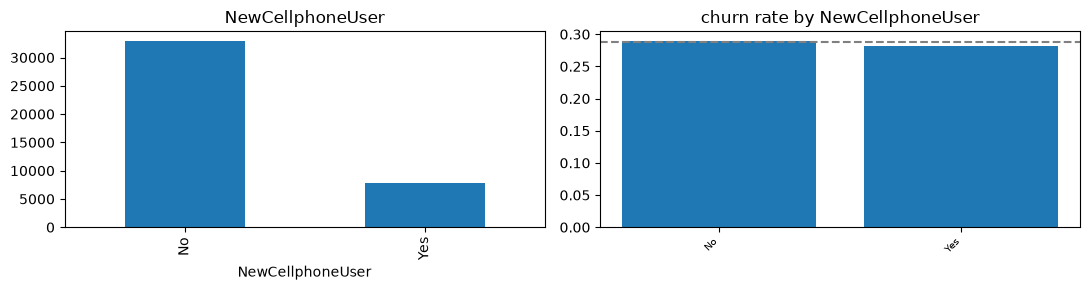

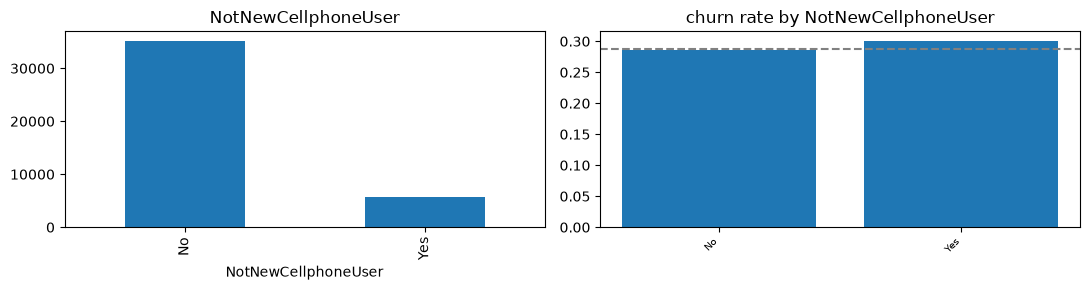

In [10]:
for c in cols:
    plot_column(train, c)

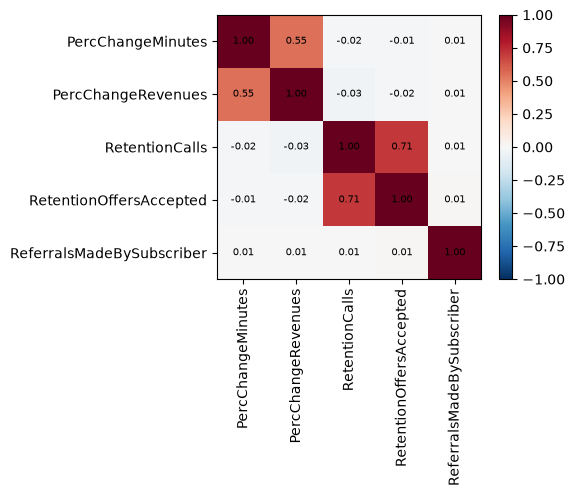

In [11]:
corr = corr_heatmap(train, cols)

**Findings (Usage change & retention (check for leakage!)):**

- Possible leakage: only ~3% of customers had contact with the retention team, but they churn at ~45% vs 28%. These features probably reflect a decision to leave that has already been made.
- ReferralsMadeBySubscriber, NewCellphoneUser and NotNewCellphoneUser show no meaningful relation to churn.
- Usage decline is linked to churn: customers whose minutes dropped most churn at ~34%, vs ~25% for customers whose usage increased.

## 4. Service quality

Columns: `DroppedCalls`, `BlockedCalls`, `UnansweredCalls`, `DroppedBlockedCalls`, `CustomerCareCalls`

In [12]:
cols = FEATURE_GROUPS["service_quality"]
display(overview(train, cols))
display(churn_signal(train, cols))

,type,n_unique,missing_%,placeholder_%,zero_%,negative_%,min,median,p99,max,top_value
column,,,,,,,,,,,
DroppedCalls,numeric,269,0.0,None,15.05,0.0,0.0,3.0,42.3,221.7,None
BlockedCalls,numeric,341,0.0,None,27.26,0.0,0.0,1.0,46.3,384.3,None
UnansweredCalls,numeric,802,0.0,None,9.73,0.0,0.0,16.3,178.7,848.7,None
DroppedBlockedCalls,numeric,417,0.0,None,11.31,0.0,0.0,5.3,71.3,411.7,None
CustomerCareCalls,numeric,176,0.0,None,54.89,0.0,0.0,0.0,21.3,327.3,None


,auc,signal
column,,
DroppedCalls,0.487,0.013
BlockedCalls,0.491,0.009
UnansweredCalls,0.472,0.028
DroppedBlockedCalls,0.485,0.015
CustomerCareCalls,0.470,0.030


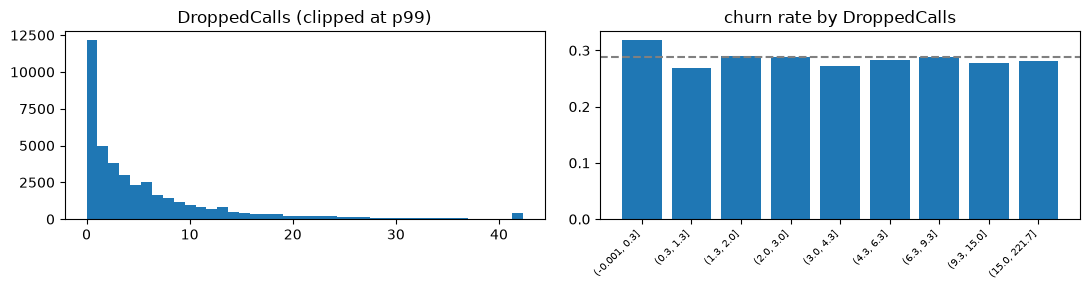

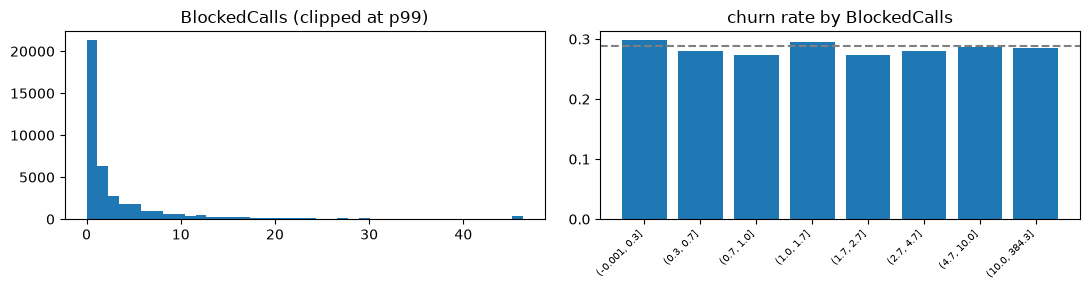

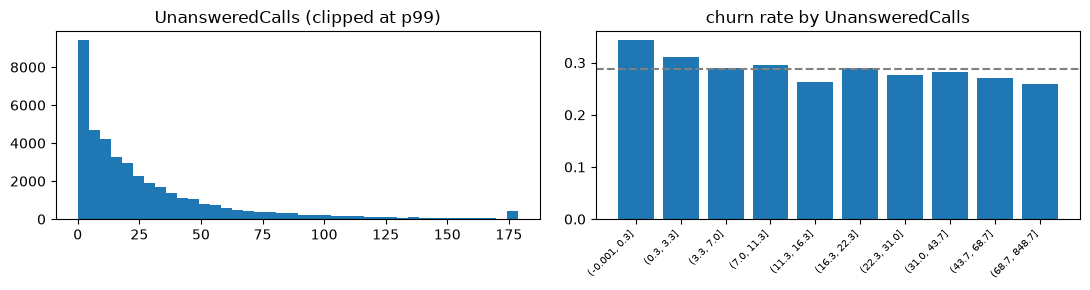

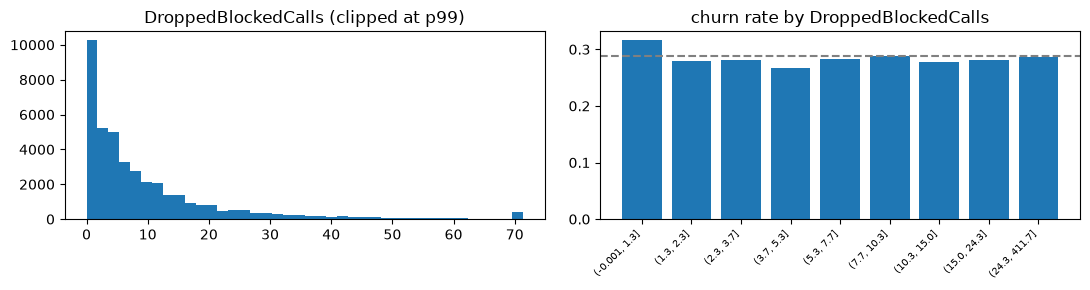

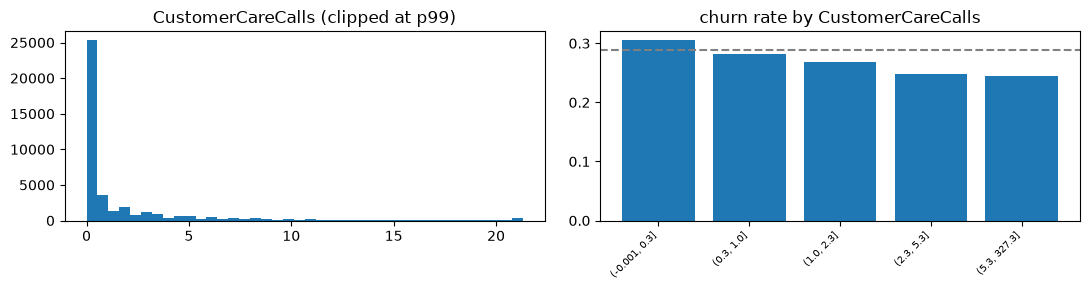

In [13]:
for c in cols:
    plot_column(train, c)

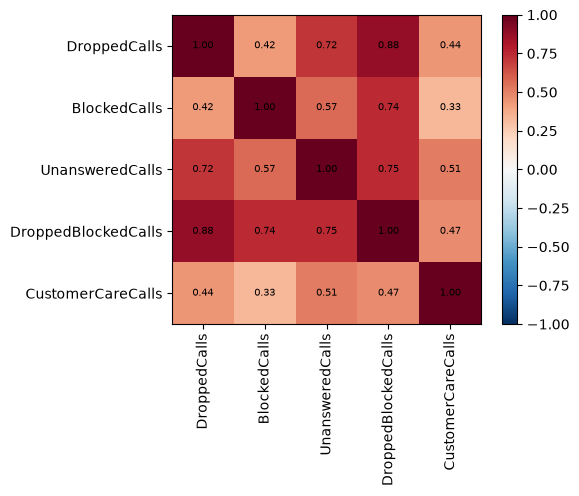

In [14]:
corr = corr_heatmap(train, cols)

**Findings (Service quality):**

- The quality counts don't behave as expected: the more unanswered calls or customer care calls a customer has, the lower their churn rate (UnansweredCalls: 34% → 26%, CustomerCareCalls: 31% → 24%).
- Customers who never contact customer care churn more (~31% vs ~24% for the most frequent callers), possibly because dissatisfied customers leave without complaining.

## 5. Demographics & region

Columns: `AgeHH1`, `AgeHH2`, `ChildrenInHH`, `IncomeGroup`, `Occupation`, `MaritalStatus`, `Homeownership`, `CreditRating`, `PrizmCode`, `ServiceArea`

In [15]:
cols = FEATURE_GROUPS["demographics_region"]
display(overview(train, cols))
display(churn_signal(train, cols))

,type,n_unique,missing_%,placeholder_%,zero_%,negative_%,min,median,p99,max,top_value
column,,,,,,,,,,,
AgeHH1,numeric,43,1.75,27.38,27.38,0.0,0.0,36.0,76.0,99.0,NaN
AgeHH2,numeric,43,1.75,51.24,51.24,0.0,0.0,0.0,76.0,99.0,NaN
ChildrenInHH,categorical,2,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
IncomeGroup,numeric,10,0.00,25.17,25.17,0.0,0.0,5.0,9.0,9.0,NaN
Occupation,categorical,8,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
MaritalStatus,categorical,3,0.00,38.57,NaN,NaN,NaN,NaN,NaN,NaN,Unknown
Homeownership,categorical,2,0.00,33.52,NaN,NaN,NaN,NaN,NaN,NaN,Known
CreditRating,categorical,7,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2-High
PrizmCode,categorical,4,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other


,auc,signal,churn_rate_min,churn_rate_max
column,,,,
AgeHH1,0.482,0.018,NaN,NaN
AgeHH2,0.491,0.009,NaN,NaN
ChildrenInHH,NaN,NaN,0.286,0.294
IncomeGroup,0.491,0.009,NaN,NaN
Occupation,NaN,NaN,0.276,0.319
MaritalStatus,NaN,NaN,0.273,0.302
Homeownership,NaN,NaN,0.284,0.297
CreditRating,NaN,NaN,0.218,0.311
PrizmCode,NaN,NaN,0.281,0.319


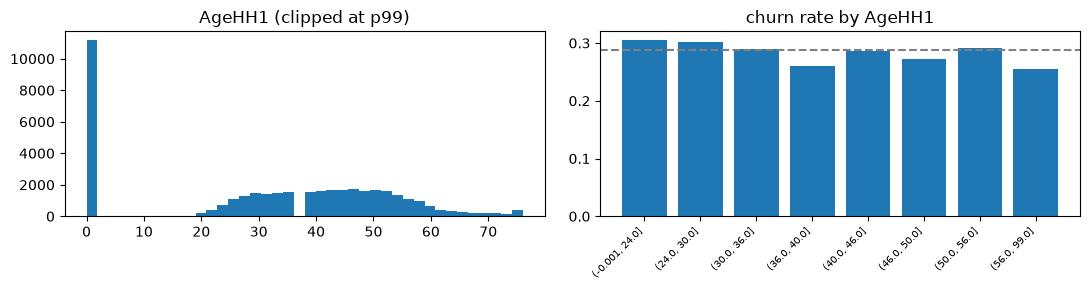

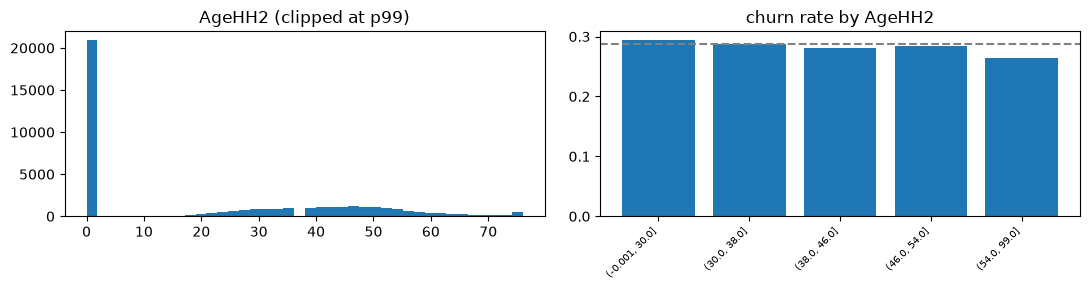

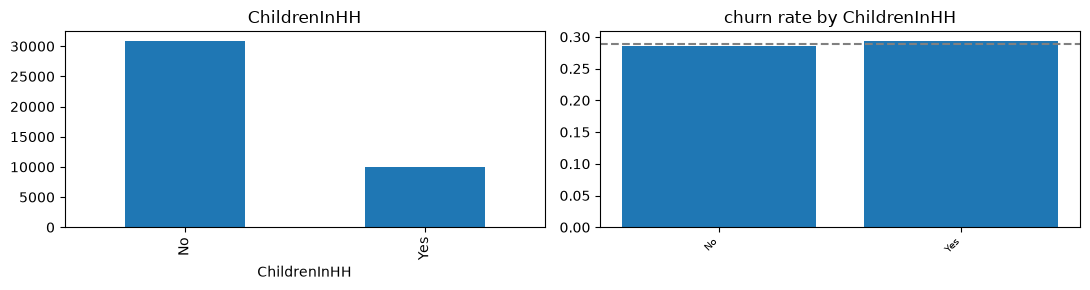

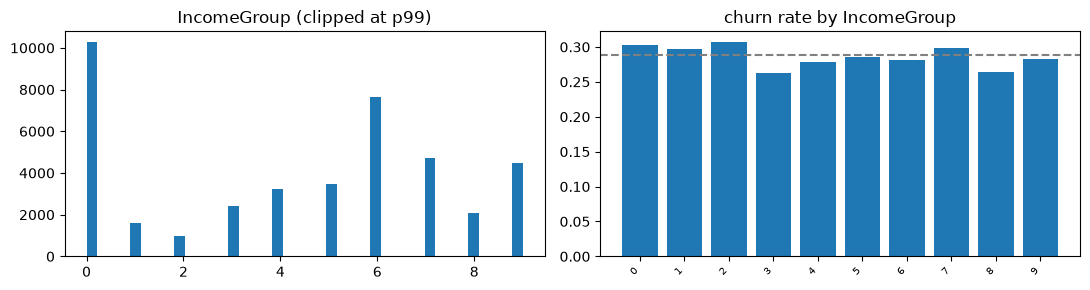

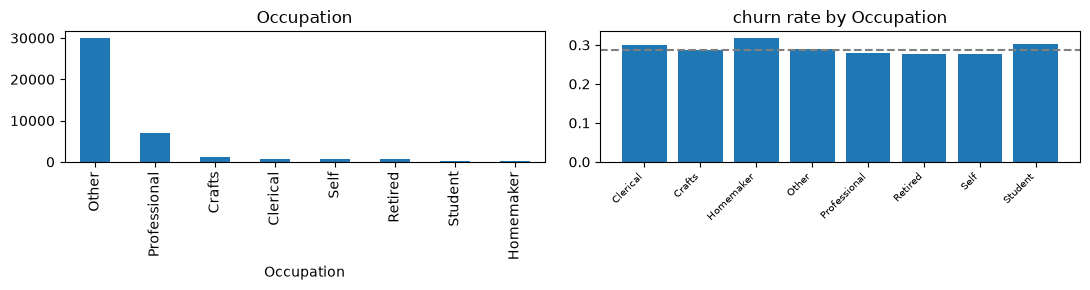

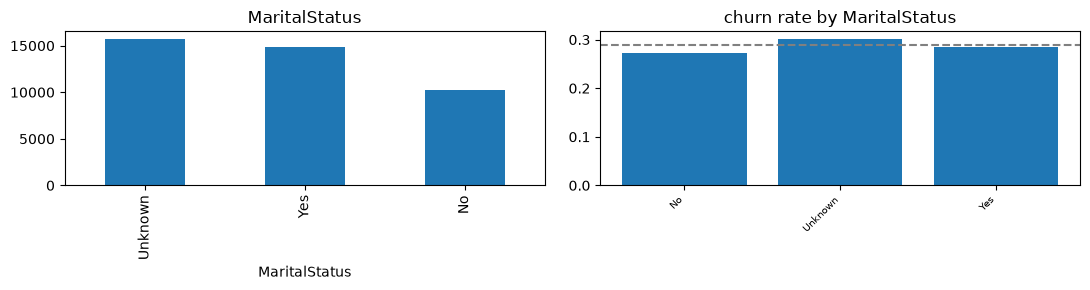

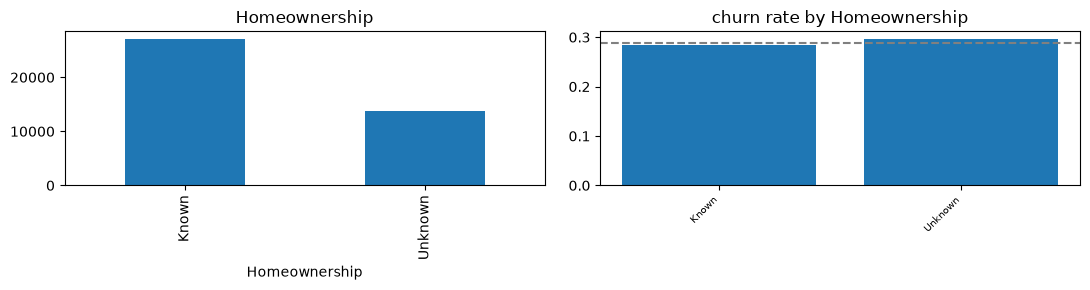

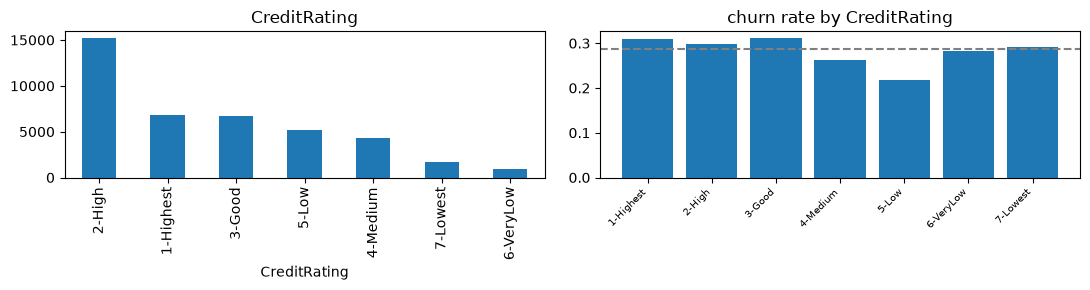

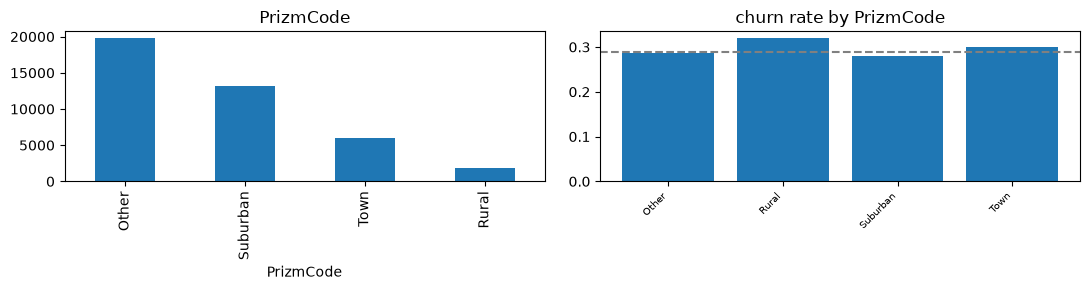

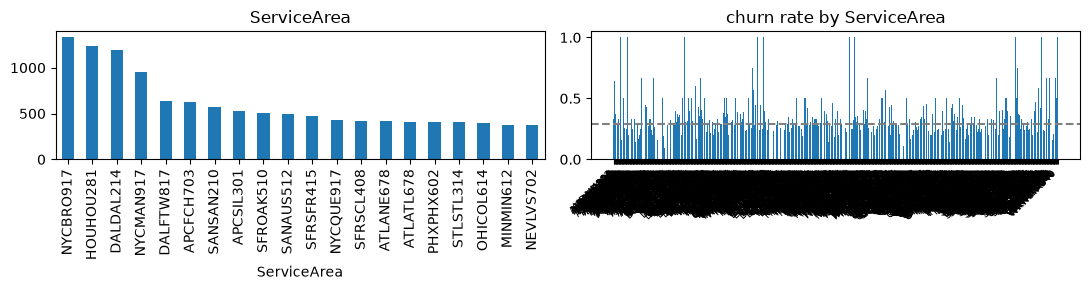

In [16]:
for c in cols:
    plot_column(train, c)

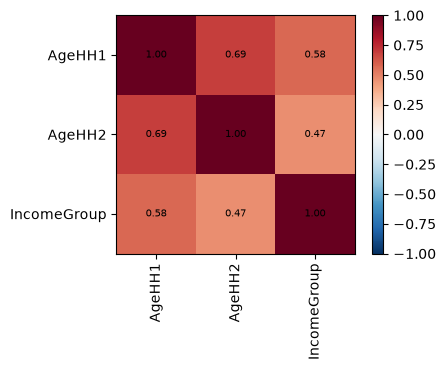

In [17]:
corr = corr_heatmap(train, cols)

**Findings (Demographics & region):**

- Demographics show little relation to churn. Age, income, occupation, marital status, homeownership and children all differ by only 1–4 percentage points between groups. 
- This group has many placeholder values: AgeHH1 = 0 (27%), AgeHH2 = 0 (51%), IncomeGroup = 0 (25%), and "Unknown" for MaritalStatus (39%) and Homeownership (34%). They tend to be missing together.
- The heatmap shows a correlation of 0.58 between age and income, but this comes from the shared zeros.

## 6. Handset & lifestyle

Columns: `HandsetPrice`, `HandsetRefurbished`, `HandsetWebCapable`, `TruckOwner`, `RVOwner`, `OwnsMotorcycle`, `OwnsComputer`, `HasCreditCard`, `BuysViaMailOrder`, `RespondsToMailOffers`, `OptOutMailings`, `NonUSTravel`

In [18]:
cols = FEATURE_GROUPS["handset_lifestyle"]
display(overview(train, cols))
display(churn_signal(train, cols))

,type,n_unique,missing_%,placeholder_%,zero_%,negative_%,min,median,p99,max,top_value
column,,,,,,,,,,,
HandsetPrice,categorical,16,0.0,56.85,None,None,None,None,None,None,Unknown
HandsetRefurbished,categorical,2,0.0,NaN,None,None,None,None,None,None,No
HandsetWebCapable,categorical,2,0.0,NaN,None,None,None,None,None,None,Yes
TruckOwner,categorical,2,0.0,NaN,None,None,None,None,None,None,No
RVOwner,categorical,2,0.0,NaN,None,None,None,None,None,None,No
OwnsMotorcycle,categorical,2,0.0,NaN,None,None,None,None,None,None,No
OwnsComputer,categorical,2,0.0,NaN,None,None,None,None,None,None,No
HasCreditCard,categorical,2,0.0,NaN,None,None,None,None,None,None,Yes
BuysViaMailOrder,categorical,2,0.0,NaN,None,None,None,None,None,None,No


,churn_rate_min,churn_rate_max
column,,
HandsetPrice,0.143,0.444
HandsetRefurbished,0.283,0.324
HandsetWebCapable,0.279,0.372
TruckOwner,0.284,0.289
RVOwner,0.282,0.289
OwnsMotorcycle,0.288,0.314
OwnsComputer,0.286,0.289
HasCreditCard,0.285,0.295
BuysViaMailOrder,0.275,0.296


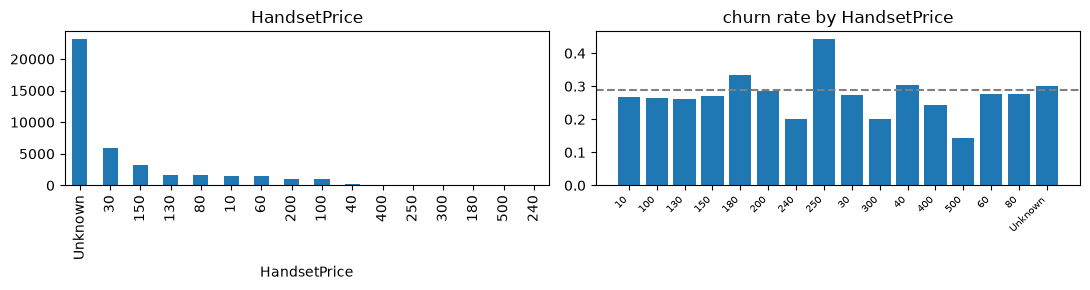

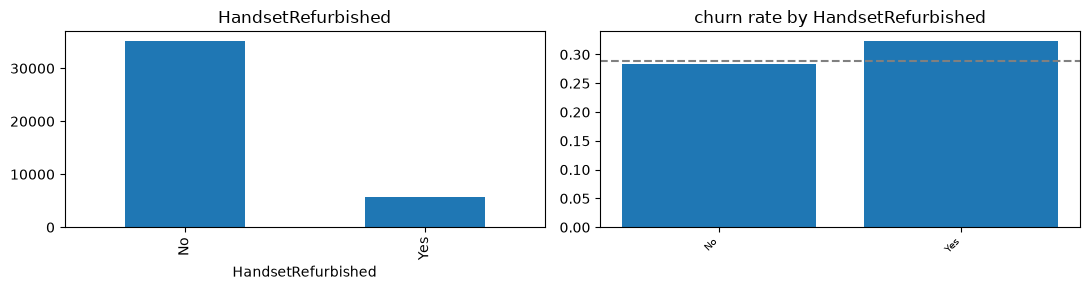

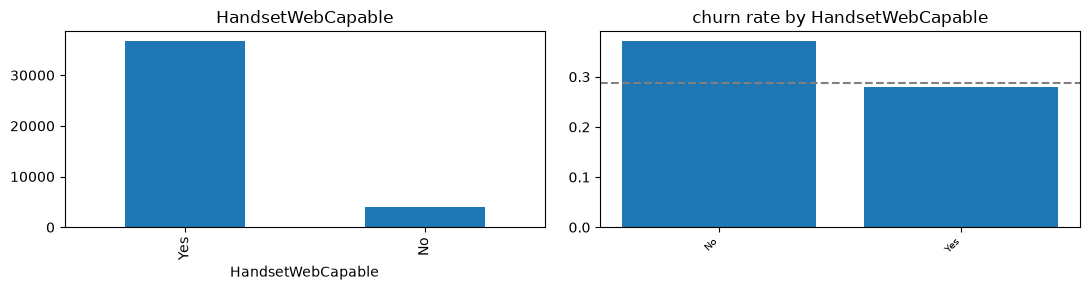

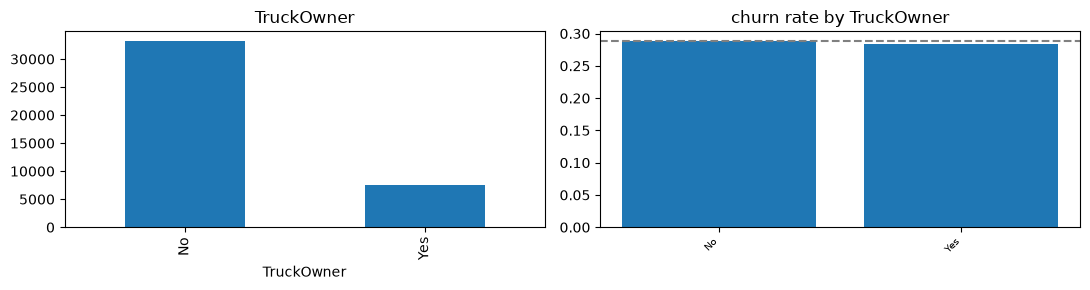

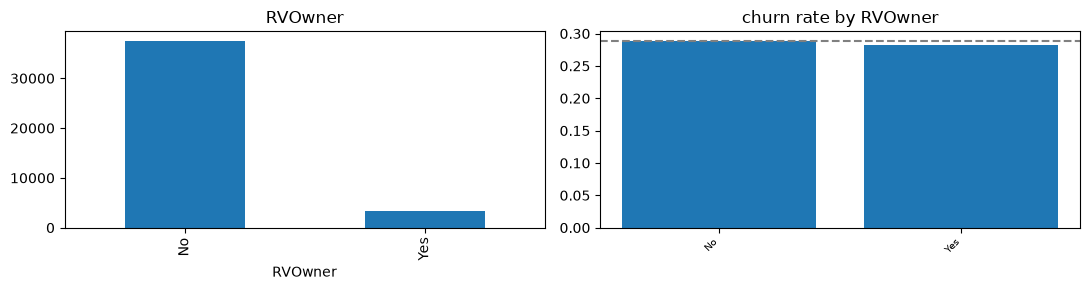

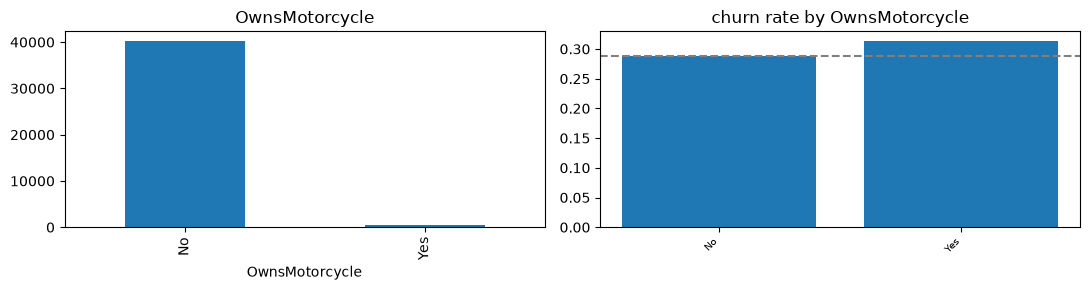

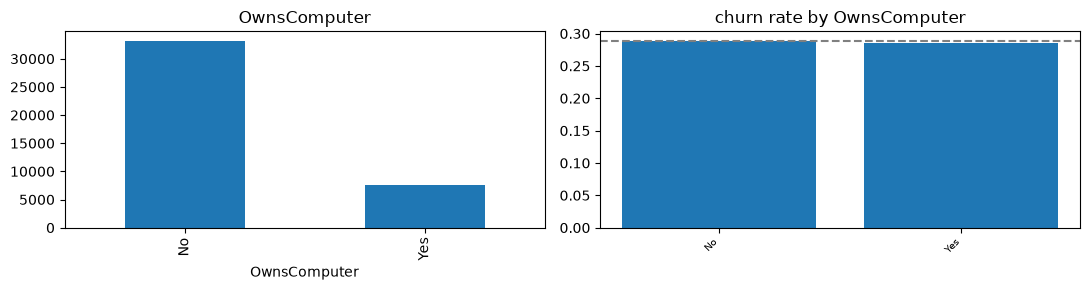

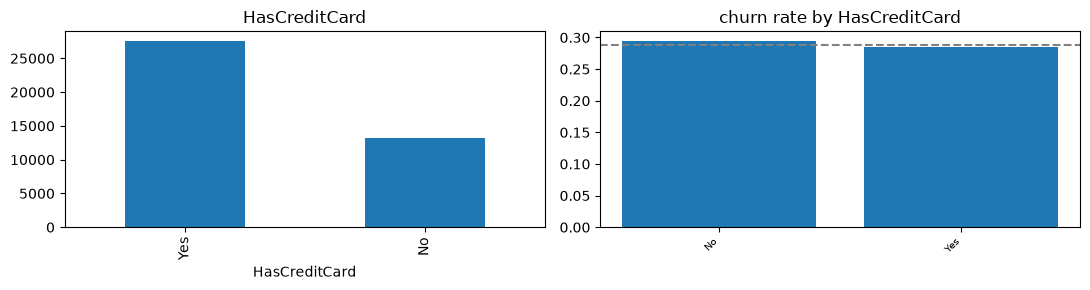

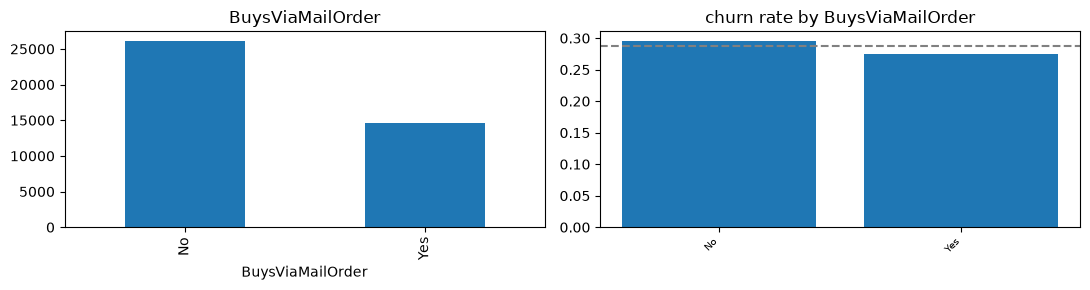

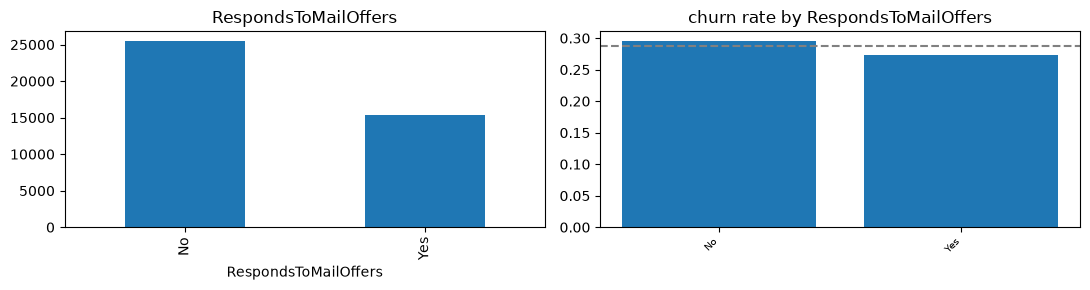

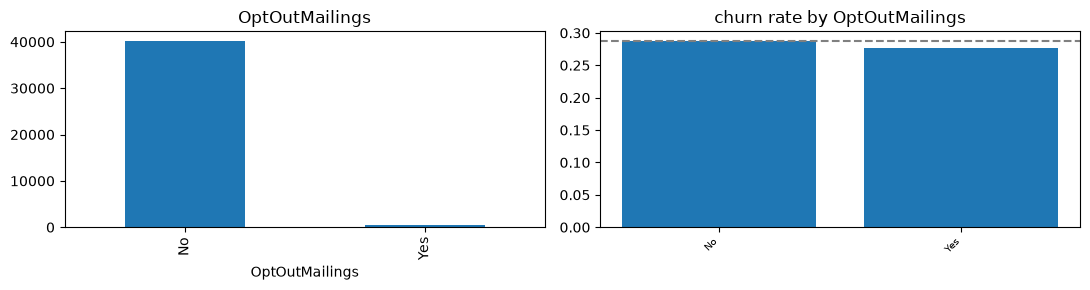

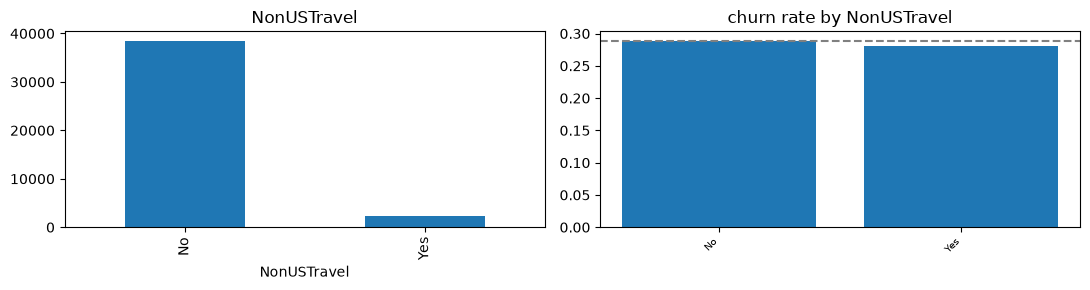

In [19]:
for c in cols:
    plot_column(train, c)

### HandsetPrice re-plotted

The default `HandsetPrice` plot above is misleading for two reasons:
1. **The x-axis is sorted as text, not by price** (10, 100, 130, …, 30, 300, 40, …), because "Unknown" makes the column a text column. This makes the bars look random.
2. **Some price levels have very few customers** (e.g. 250 has only 18, 500 only 7), so their churn rates (44%, 14%) are not reliable.

Below, the left plot shows every price level **sorted by price** with the number of customers on each bar; the right plot **groups prices into ranges** so that each bar is based on enough customers.

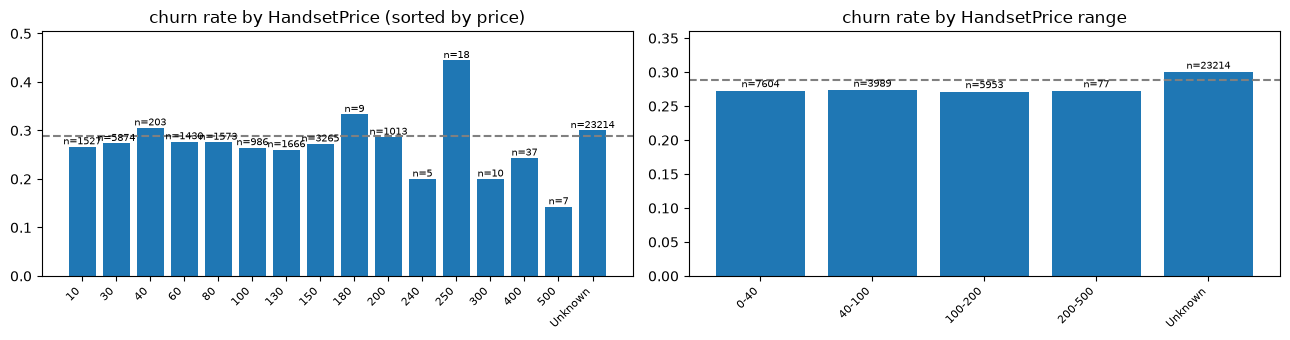

,n,churn_rate
0-40,7604,0.273
40-100,3989,0.274
100-200,5953,0.271
200-500,77,0.273
Unknown,23214,0.300


In [20]:
import matplotlib.pyplot as plt

price = pd.to_numeric(train["HandsetPrice"], errors="coerce")  # "Unknown" -> NaN
unknown = train.loc[price.isna(), "churn"]

# every price level, sorted by price
by_price = train.groupby(price)["churn"].agg(["size", "mean"])
labels = [str(int(p)) for p in by_price.index] + ["Unknown"]
rates = list(by_price["mean"]) + [unknown.mean()]
sizes = list(by_price["size"]) + [len(unknown)]

# price ranges
ranges = pd.cut(price, [0, 40, 100, 200, 500], labels=["0-40", "40-100", "100-200", "200-500"])
by_range = train.groupby(ranges, observed=True)["churn"].agg(["size", "mean"])
range_labels = list(by_range.index.astype(str)) + ["Unknown"]
range_rates = list(by_range["mean"]) + [unknown.mean()]
range_sizes = list(by_range["size"]) + [len(unknown)]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, lab, rate, n, title in [
        (axes[0], labels, rates, sizes, "churn rate by HandsetPrice (sorted by price)"),
        (axes[1], range_labels, range_rates, range_sizes, "churn rate by HandsetPrice range")]:
    bars = ax.bar(range(len(rate)), rate)
    ax.set_xticks(range(len(rate)), lab, rotation=45, ha="right", fontsize=8)
    ax.axhline(train["churn"].mean(), ls="--", c="grey")
    for b, k in zip(bars, n):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005, f"n={k}", ha="center", fontsize=7)
    ax.set_title(title)
    ax.set_ylim(0, max(rate) + 0.06)
plt.tight_layout()
plt.show()

pd.DataFrame({"n": range_sizes, "churn_rate": [round(r, 3) for r in range_rates]}, index=range_labels)

**Findings (Handset & lifestyle):**

- Customers whose handset cannot access the web churn much more (37% vs 28%). These are mostly old phones.
- Refurbished handsets also go with higher churn (32% vs 28%), but they are not older, so the effect is not about handset age.
- The nine lifestyle and marketing features (TruckOwner, RVOwner, OwnsMotorcycle, OwnsComputer, HasCreditCard, BuysViaMailOrder, RespondsToMailOffers, OptOutMailings, NonUSTravel) show almost no difference in churn (0.5–2 percentage points) → candidates to drop. 

## 7. Cross-group checks

Checks that look at several columns together. Run them and note what they mean for preprocessing.

### 7.1 Redundant columns
Are some columns (almost) derived from others? If yes, we may only need one of them.

In [21]:
dbc = train["DroppedCalls"] + train["BlockedCalls"]
print("DroppedBlockedCalls == DroppedCalls + BlockedCalls:",
      round(((train["DroppedBlockedCalls"] - dbc).abs() < 0.11).mean(), 3))
print(pd.crosstab(train["NewCellphoneUser"], train["NotNewCellphoneUser"]))
print(pd.crosstab(train["Handsets"].clip(upper=5), train["HandsetModels"].clip(upper=5)))
print(pd.crosstab(train["UniqueSubs"].clip(upper=5), train["ActiveSubs"].clip(upper=5)))

DroppedBlockedCalls == DroppedCalls + BlockedCalls: 0.967
NotNewCellphoneUser     No   Yes
NewCellphoneUser                
No                   27363  5620
Yes                   7854     0
HandsetModels    1.0   2.0   3.0  4.0  5.0
Handsets                                  
1.0            23117     0     0    0    0
2.0             2113  7993     0    0    0
3.0              213  1840  1988    0    0
4.0               46   447   871  456    0
5.0               11   139   438  574  590
ActiveSubs   0      1     2     3    4    5
UniqueSubs                                 
1           22  25707     0     0    0    0
2            5   2768  8299     0    0    0
3            3    436   954  1148    0    0
4            1    101   377   239  246    0
5            1     42   100   137  109  142


### 7.2 Are placeholder values informative?
If customers with an "unknown" value churn more or less than others, a missing-indicator feature is useful.

In [22]:
from src.eda_utils import PLACEHOLDERS

rows = []
for c, v in PLACEHOLDERS.items():
    is_ph = train[c] == v
    rows.append({"column": c, "placeholder": v, "share": round(is_ph.mean(), 3),
                 "churn_if_placeholder": round(train.loc[is_ph, "churn"].mean(), 3),
                 "churn_otherwise": round(train.loc[~is_ph, "churn"].mean(), 3)})
pd.DataFrame(rows).set_index("column")

,placeholder,share,churn_if_placeholder,churn_otherwise
column,,,,
AgeHH1,0,0.274,0.302,0.283
AgeHH2,0,0.512,0.293,0.284
IncomeGroup,0,0.252,0.303,0.283
HandsetPrice,Unknown,0.568,0.300,0.273
MaritalStatus,Unknown,0.386,0.302,0.279
Homeownership,Unknown,0.335,0.297,0.284


### 7.3 Churn by tenure, month by month
Is there a point in time where churn suddenly changes (e.g. contract expiry)?

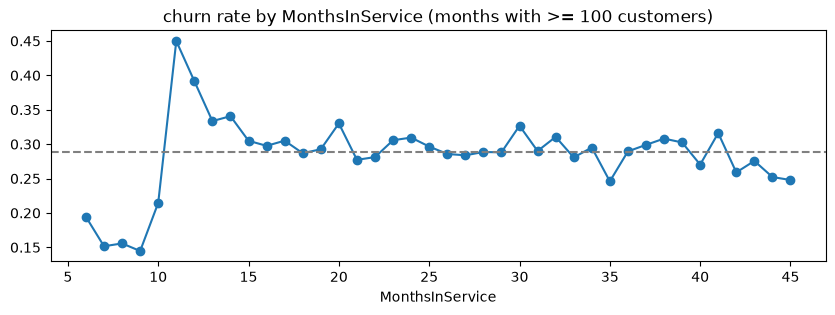

In [23]:
rate = train.groupby("MonthsInService")["churn"].agg(["size", "mean"])
rate = rate[rate["size"] >= 100]
ax = rate["mean"].plot(marker="o", figsize=(10, 3), title="churn rate by MonthsInService (months with >= 100 customers)")
ax.axhline(train["churn"].mean(), ls="--", c="grey");

### 7.4 Tenure × spending segments
These segments will be used later for the error analysis (which groups contain the most missed churners).

In [24]:
tenure_grp = pd.cut(train["MonthsInService"], [0, 10, 12, 24, 1000], labels=["6-10m", "11-12m", "13-24m", ">24m"])
spend_grp = pd.qcut(train["MonthlyRevenue"], 3, labels=["low", "mid", "high"])
display(pd.crosstab(tenure_grp, spend_grp))                                          # size
display(pd.crosstab(tenure_grp, spend_grp, values=train["churn"], aggfunc="mean").round(3))  # churn rate

MonthlyRevenue,low,mid,high
MonthsInService,,,
6-10m,2414,3098,2997
11-12m,1667,1735,1688
13-24m,5880,5626,5557
>24m,3613,3112,3330


MonthlyRevenue,low,mid,high
MonthsInService,,,
6-10m,0.173,0.145,0.187
11-12m,0.427,0.418,0.428
13-24m,0.312,0.307,0.302
>24m,0.323,0.284,0.250


**Findings (cross-group):**

- DroppedBlockedCalls equals DroppedCalls + BlockedCalls for 96.7% of customers → redundant, drop it.
- NewCellphoneUser and NotNewCellphoneUser are never both "Yes". Together they describe one variable with three levels: new, not new and unknown → merge into one feature.
- HandsetModels ≤ Handsets and ActiveSubs ≤ UniqueSubs for every customer. The pairs are closely related but not identical, so we keep one of each pair. 

## 8. Your own analysis (required)

Sections 0–7 produce the same numbers for everyone. This section is where your own exploration goes: **do at least 1 analyses that are not in this template** and write down what you find.

Some directions, if you need ideas:
- **Interactions:** e.g. do high-spending customers whose usage dropped churn especially often?
- **Try a new feature:** e.g. dropped calls / total calls; is it more related to churn than the raw count?
- **Different binning or grouping:** e.g. `CurrentEquipmentDays` in years
- **Sub-groups:** e.g. among customers at 11–12 months (contract expiry), which features separate churners from non-churners?
- **Check an assumption:** e.g. are customers with many customer care calls simply heavy users?
- **Other statistics:** e.g. chi-square test for categorical features

Add as many cells as you need.

### 8.1 Service quality as a rate instead of a count

In section 4, more dropped or unanswered calls went with slightly *lower* churn, which is counter-intuitive. Question: do these counts mainly measure how much a customer calls? If so, a rate (dropped calls per call) should show the real effect of service quality.

In [30]:
from sklearn.metrics import roc_auc_score

# (a) how strongly do the quality counts follow usage?
quality = ["DroppedCalls", "BlockedCalls", "UnansweredCalls", "CustomerCareCalls"]
display(train[quality].corrwith(train["MonthlyMinutes"], method="spearman").round(2).to_frame("corr_with_MonthlyMinutes"))

# (b) dropped-call rate = dropped calls / all calls (peak + off-peak)
calls = train["PeakCallsInOut"] + train["OffPeakCallsInOut"]
dropped_rate = train["DroppedCalls"] / calls.where(calls > 0)
print("share of customers with rate > 1 (dropped > total calls):", round((dropped_rate > 1).mean(), 4))

rate_q = pd.qcut(dropped_rate, 5, duplicates="drop")
display(train.groupby(rate_q, observed=True)["churn"].agg(["size", "mean"]).round(3))
print("AUC raw DroppedCalls:", round(roc_auc_score(train["churn"], train["DroppedCalls"]), 3))
m = dropped_rate.notna()
print("AUC dropped_rate:    ", round(roc_auc_score(train.loc[m, "churn"], dropped_rate[m]), 3))

,corr_with_MonthlyMinutes
DroppedCalls,0.66
BlockedCalls,0.46
UnansweredCalls,0.70
CustomerCareCalls,0.48


share of customers with rate > 1 (dropped > total calls): 0.0005


,size,mean
"(-0.001, 0.0122]",7519,0.269
"(0.0122, 0.0243]",7518,0.269
"(0.0243, 0.0386]",7521,0.274
"(0.0386, 0.0626]",7515,0.283
"(0.0626, 7.667]",7519,0.316


AUC raw DroppedCalls: 0.487
AUC dropped_rate:     0.521


**Findings (own analysis):**

- The raw quality counts mostly measure how much a customer calls. UnansweredCalls and DroppedCalls are strongly correlated with MonthlyMinutes (0.70 and 0.66). Heavy users have more dropped calls simply because they make more calls, and they also churn less, which explains the counter-intuitive pattern in section 4.

## 9. Decision table

Fill in one row per feature. Keep entries short. Suggested values:
- `keep_drop`: keep / drop / unsure
- `missing_handling`: none / median / mode / placeholder→NaN + indicator / ...
- `transformation`: none / log1p / clip at p99 / clip at 0 / binarise / ...
- `encoding`: numeric / binary 0-1 / ordinal / one-hot / target encoding / ...

Fill in one line per feature as shown in the comment (the syntax only, not a suggested decision).

In [28]:
summary = summary_skeleton()

FIELDS = ["issues", "relation_to_churn", "keep_drop", "missing_handling", "transformation", "encoding", "feature_ideas"]
# summary.loc["<column>", FIELDS] = ["<issues>", "<relation to churn>", "<keep/drop/unsure>", "<missing handling>", "<transformation>", "<encoding>", "<feature ideas>"]

summary

,group,issues,relation_to_churn,keep_drop,missing_handling,transformation,encoding,feature_ideas
column,,,,,,,,
MonthlyRevenue,account_billing,,,,,,,
TotalRecurringCharge,account_billing,,,,,,,
OverageMinutes,account_billing,,,,,,,
MonthsInService,account_billing,,,,,,,
CurrentEquipmentDays,account_billing,,,,,,,
Handsets,account_billing,,,,,,,
HandsetModels,account_billing,,,,,,,
UniqueSubs,account_billing,,,,,,,
ActiveSubs,account_billing,,,,,,,


In [29]:
NAME = "yourname"  # <- change
summary.to_csv(f"summaries/eda_summary_{NAME}.csv")